In [1]:
import pandas as pd
import numpy as np
import os, sys
from matplotlib import pyplot as plt
from scipy import stats
import pickle as pk

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), os.pardir)))
from customFunctions.utils import *

In [2]:
mithril_features = pd.read_csv("../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


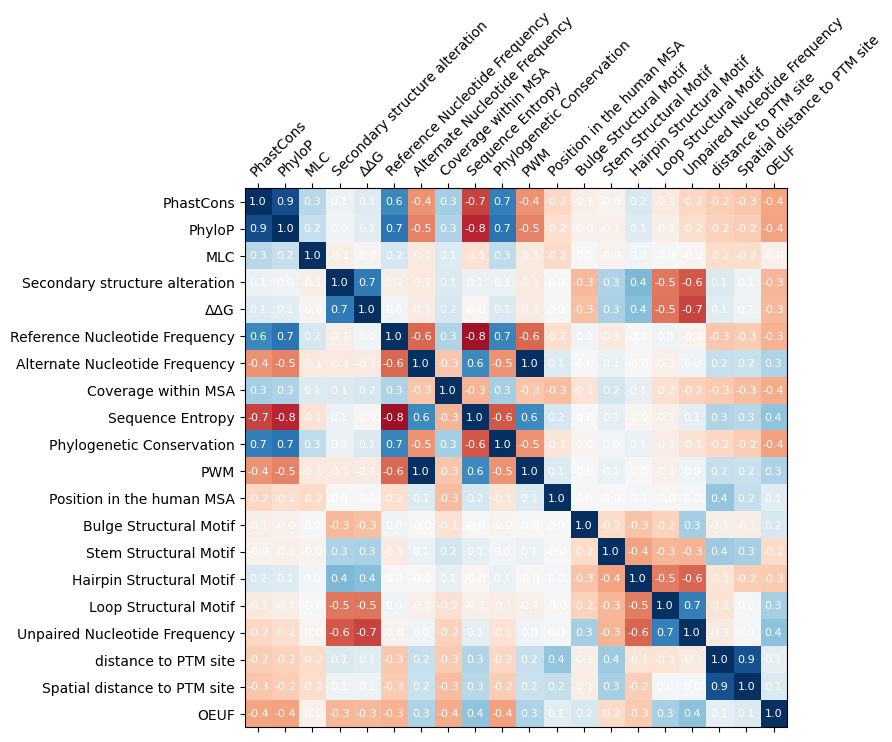

In [3]:
plt.figure(figsize=(7,7))
plt.matshow(
    mithril_features.corr(method="spearman"),
    cmap="RdBu", aspect="auto", fignum=0, vmin=-1, vmax=1
)
plt.xticks(range(mithril_features.shape[1]), [feature_name_conversion(featurename) for featurename in mithril_features.columns], rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(mithril_features.shape[1]), [feature_name_conversion(featurename) for featurename in mithril_features.columns])
for i in range(mithril_features.shape[1]):
    for j in range(mithril_features.shape[1]):
        plt.text(i, j, f"{mithril_features.corr(method='spearman').iloc[i, j]:.1f}", ha="center", va="center", color="w", fontsize=8)
plt.show()

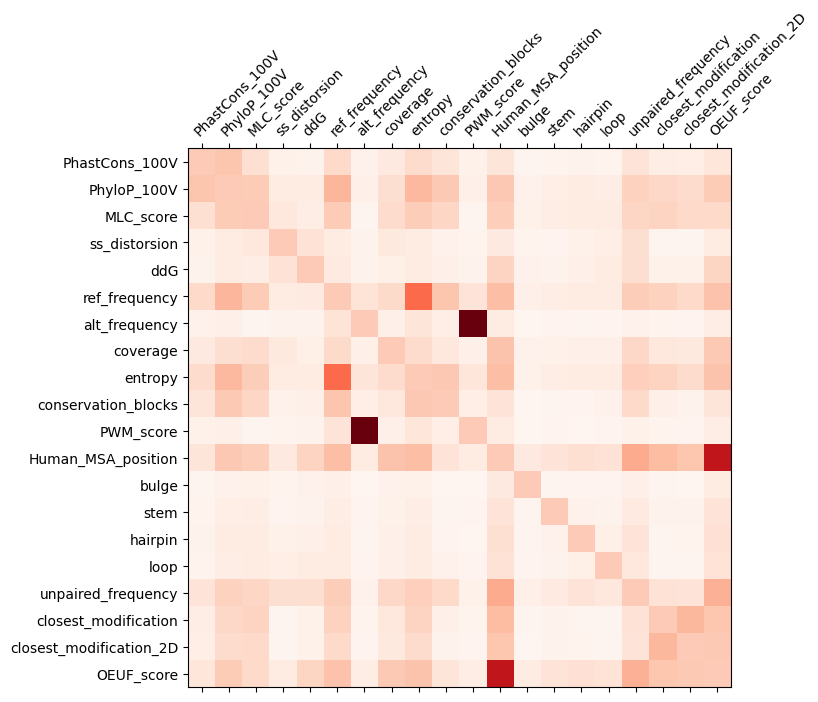

In [ ]:
from sklearn.feature_selection import mutual_info_regression
plt.figure(figsize=(7,7))
plt.matshow(
    mithril_features.corr(lambda x, y: mutual_info_regression(x[:,None], y, n_neighbors=5)),
    cmap="Reds", aspect="auto", fignum=0, vmin=0
)
plt.xticks(range(mithril_features.shape[1]), mithril_features.columns, rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(mithril_features.shape[1]), mithril_features.columns)
plt.show()

In [5]:
model = pk.load(open("../checkpoints/candidate_models/model_svc.pk", "rb"))
model

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x747d030d5c60>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x747d03340400>, verbose=2)